(lecture09:homework)=
# Homework 9

+ Type your name and email in the "Student details" section below.
+ Develop the code and generate the figures you need to solve the problems using this notebook.
+ For the answers that require a mathematical proof or derivation you can either:
    
    - Type the answer using the built-in latex capabilities. In this case, simply export the notebook as a pdf and upload it on gradescope; or
    - You can print the notebook (after you are done with all the code), write your answers by hand, scan, turn your response to a single pdf, and upload on gradescope.

+ The total homework points are 100. Please note that the problems are not weighed equally.

```{note}
+ Please match all the pages corresponding to each of the questions when you submit on gradescope.
```

## Student details

+ **First Name:** Isabela
+ **Last Name:** Tassone Haddad
+ **Email:** itassone@purdue.edu

In [1]:
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set(rc={"figure.dpi":100, 'savefig.dpi':300})
sns.set_context('notebook')
sns.set_style("ticks")
from IPython.display import set_matplotlib_formats
set_matplotlib_formats('retina', 'svg')
import numpy as np
import scipy.stats as st

/tmp/ipykernel_259/122018214.py:8: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  set_matplotlib_formats('retina', 'svg')


(lecture09:homework:problem1)=
## Problem 1: Predicting the probability of major earthquakes in Southern California

We are going to revisit the {ref}`lecture07:homework:problem2`, but this time we are going to use a Poisson distribution to carry out our analysis.

The [San Andreas fault](https://en.wikipedia.org/wiki/San_Andreas_Fault) extends through California forming the boundary between the Pacific and the North American tectonic plates.
It has caused some of the major earthquakes on Earth.
We are going to focus on Southern California and we would like to assess the probability of a major earthquake, defined as an earthquake of magnitude 6.5 or greater, during the next ten years.

The first thing we are going to do is go over a [database of past earthquakes](https://scedc.caltech.edu/significant/chron-index.html) that have occured in Southern California and collect the relevant data. We are going to start at 1900 because data before that time may are unreliable.
Go over each decade and count the occurence of a major earthquake (i.e., count the number of organge and red colors in each decade). I have done this for you.

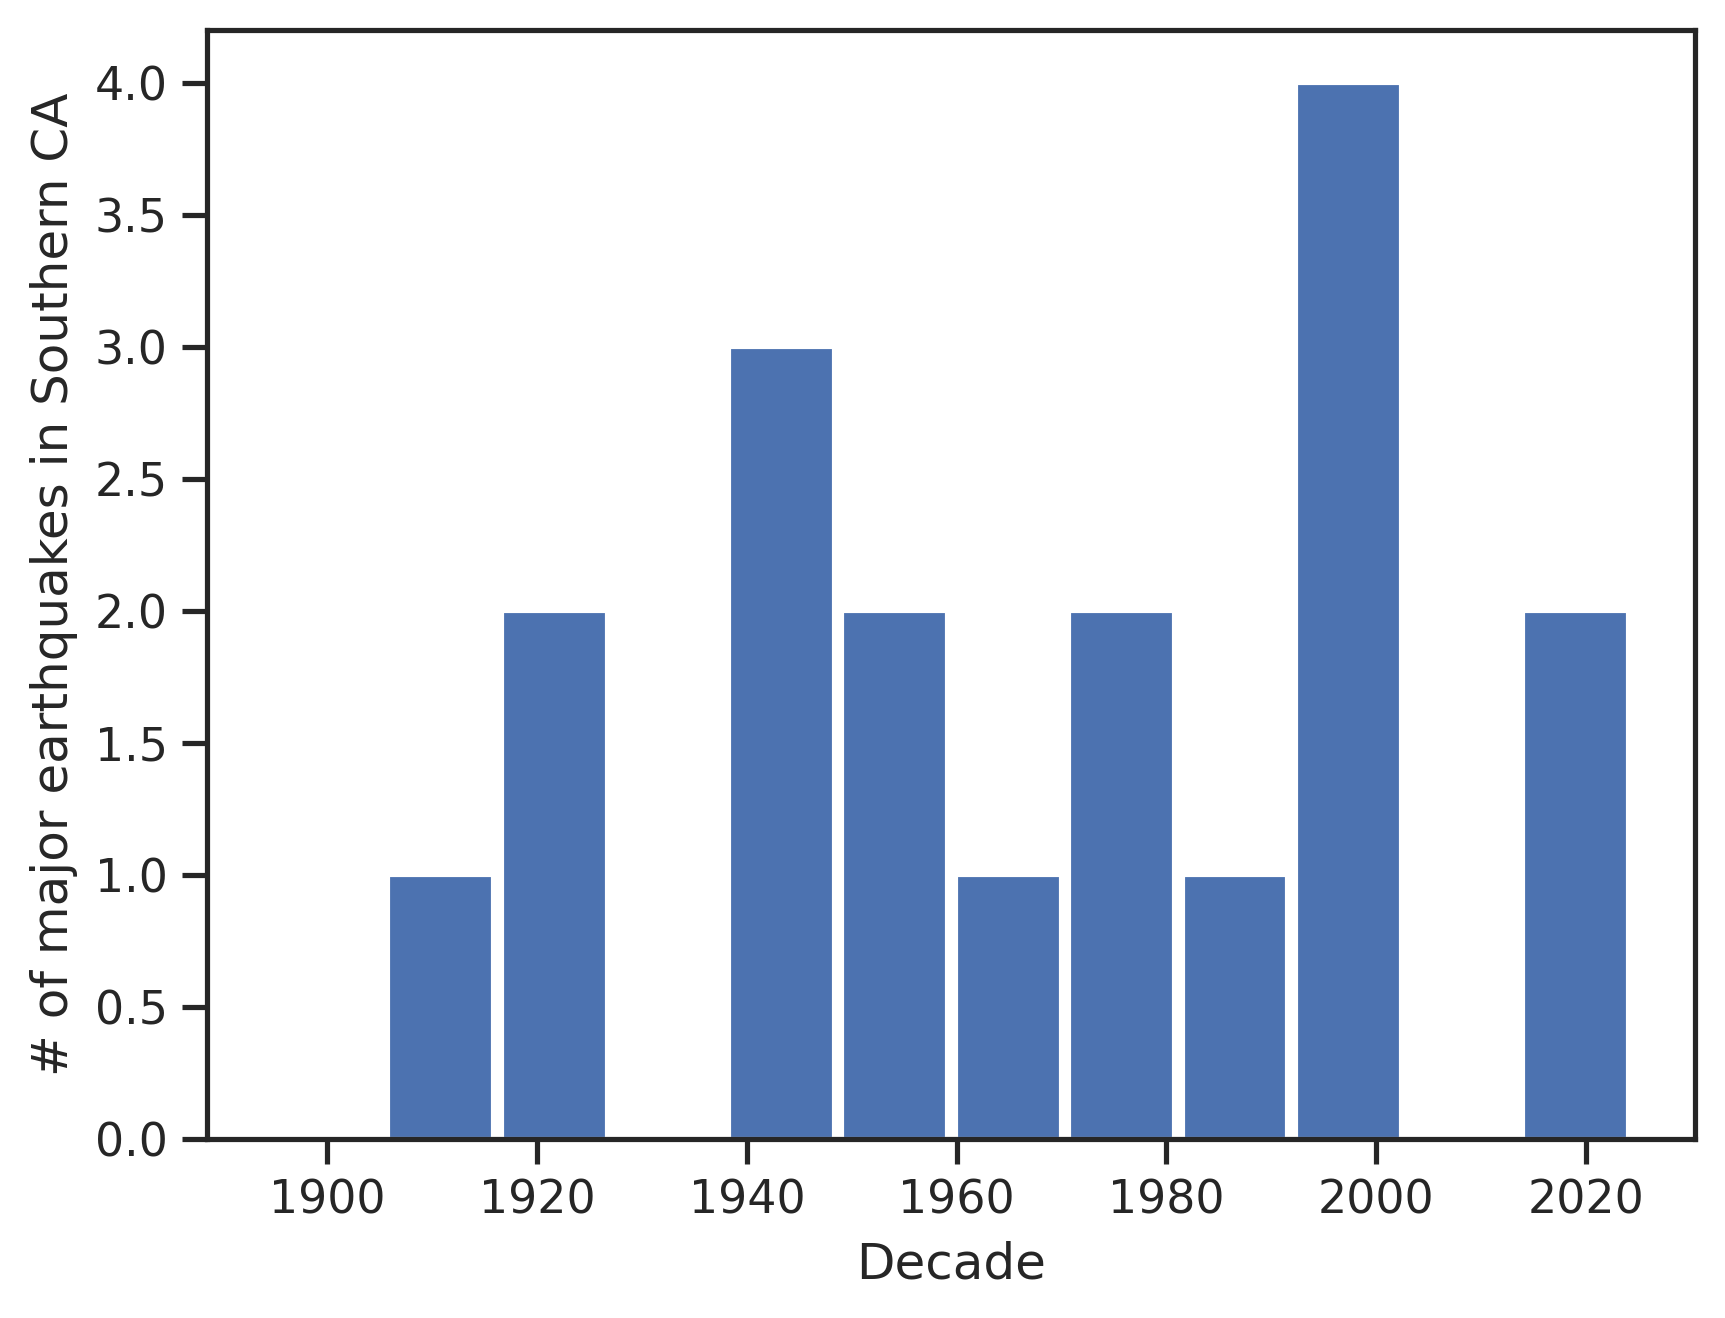

In [2]:
eq_data = np.array([
    0, # 1900-1909
    1, # 1910-1919
    2, # 1920-1929
    0, # 1930-1939
    3, # 1940-1949
    2, # 1950-1959
    1, # 1960-1969
    2, # 1970-1979
    1, # 1980-1989
    4, # 1990-1999
    0, # 2000-2009
    2 # 2010-2019
])
fig, ax = plt.subplots(dpi=150)
ax.bar(np.linspace(1900, 2019, eq_data.shape[0]), eq_data, width=10)
ax.set_xlabel('Decade')
ax.set_ylabel('# of major earthquakes in Southern CA');

Let's use the Poisson to model the number of earthquakes $X$ occuring in a decade.
We write:
$$
X \sim \operatorname{Poisson}(r),
$$
where $r$ is the *rate parameter* of Poisson.
The rate is the number of events per time period.
Here, $r$ is the number of earthquakes per decade.


+ Use the `eq_data` to find the rate $r$ of the Poisson. We can set it as the empirical average of the observed number of earthquakes per decade:

In [6]:
import numpy as np

eq_data = np.array([0,1,2,0,3,2,1,2,1,4,0,2])

r = np.mean(eq_data)
print(f"r = {r}")

r = 1.5


+ Initialize a Poisson random variable $X$ with rate parameter $r$ using `scipy.stats`. Hint: See {ref}`lecture09:the-poisson-distribution`.

In [8]:
from scipy.stats import poisson
X = poisson(mu=r)

+ Plot the probability mass function of $X$.

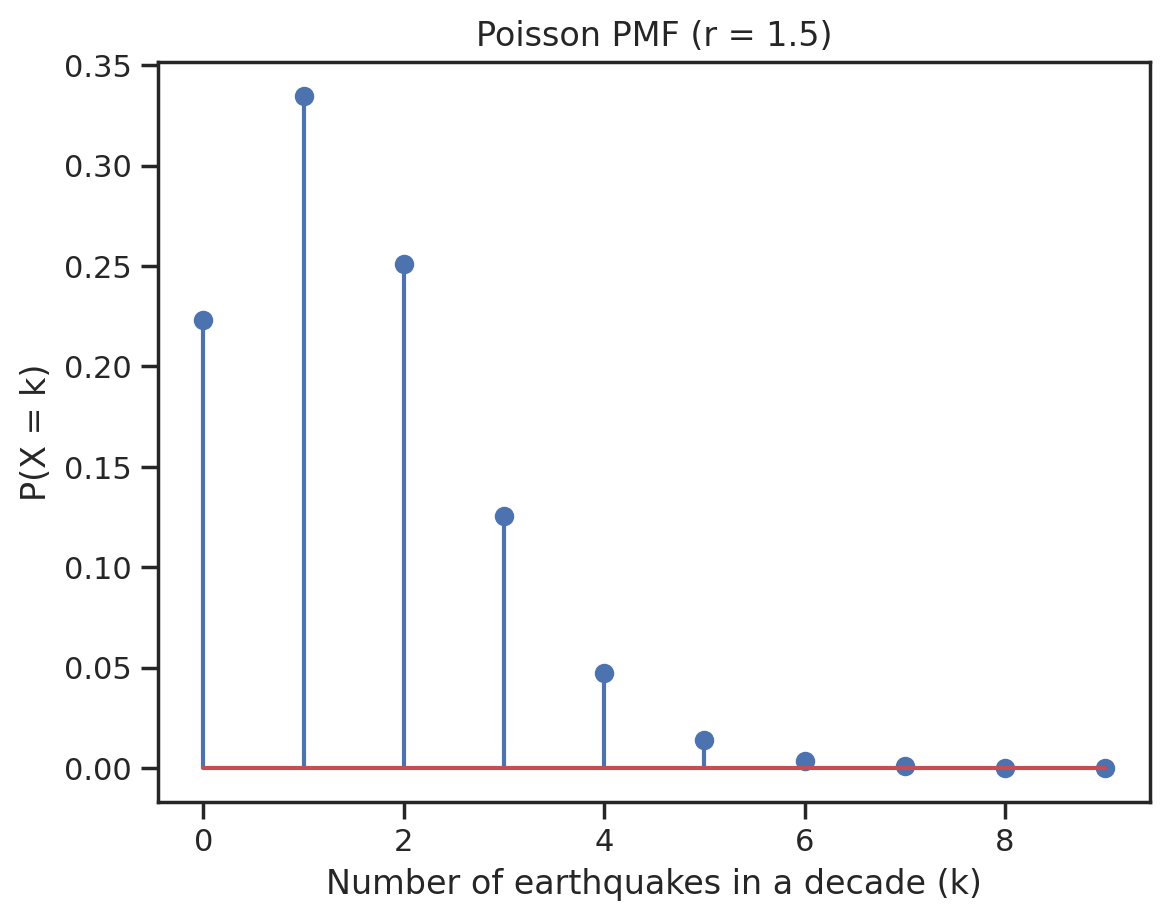

In [9]:
import matplotlib.pyplot as plt

k = np.arange(0,10)   # possible earthquake counts

pmf = X.pmf(k)

plt.stem(k, pmf)
plt.xlabel("Number of earthquakes in a decade (k)")
plt.ylabel("P(X = k)")
plt.title("Poisson PMF (r = 1.5)")
plt.show()

+ What is the probability that no major earthquake will occur during the next decade?

**Answer:**

In [14]:
p_no_eq = X.pmf(0)

print(f"The probability of no major earthquake in the next decade is {p_no_eq:.2f}")

The probability of no major earthquake in the next decade is 0.22


+ What is the probability that one or two major earthquakes will occur during the next decade?

**Answer:**

In [11]:
p = X.pmf(1) + X.pmf(2)

print(f"The probability that one or two major earthquakes occur in the next decade is {p:.3f}")

The probability that one or two major earthquakes occur in the next decade is 0.586


+ What is the probability that at least one major earthquake will occur during the next decade? Hint: Use the obvious rule.

**Answer:**

In [12]:
p_at_least_one = 1 - X.pmf(0)

print(f"The probability that at least one major earthquake occurs in the next decade is {p_at_least_one:.3f}")

The probability that at least one major earthquake occurs in the next decade is 0.777


Run the following code to convert the notebook to a pdf. Verify that the file path to the notebook is correct.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
!apt-get install inkscape texlive texlive-xetex texlive-latex-extra pandoc --quiet
!pip install pypandoc --quiet
!jupyter nbconvert --to PDF '/content/drive/MyDrive/Colab Notebooks/Copy of homework_09.ipynb'